In [31]:
import polars as pl

df_raw = pl.read_parquet("../parquets/B_dreamdex_weth_top_of_book.parquet")
df = df_raw.unique().sort("seq_id")

pl.DataFrame({
    "stage": ["raw", "deduped_and_seq_sorted"],
    "rows": [df_raw.height, df.height],
    "columns": [df_raw.width, df.width],
})

stage,rows,columns
str,i64,i64
"""raw""",6988,9
"""deduped_and_seq_sorted""",6988,9


In [32]:
df.null_count()

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,6988,6988,0,1540,1540,0,0


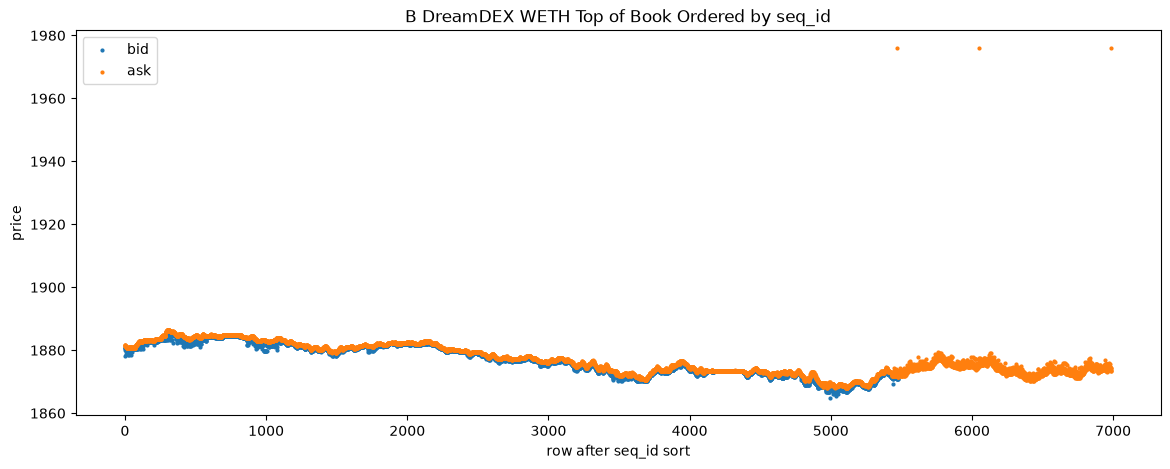

In [33]:
import polars as pl
import matplotlib.pyplot as plt

df_raw = pl.read_parquet("../parquets/B_dreamdex_weth_top_of_book.parquet")
df = df_raw.unique().sort("seq_id")

df_seq = df.with_row_index("row")

plt.figure(figsize=(14, 5))
plt.scatter(df_seq["row"], df_seq["bid_price"], s=4, label="bid")
plt.scatter(df_seq["row"], df_seq["ask_price"], s=4, label="ask")
plt.title("B DreamDEX WETH Top of Book Ordered by seq_id")
plt.xlabel("row after seq_id sort")
plt.ylabel("price")
plt.legend()
plt.show()

In [34]:
df = df.with_columns(
    missing_bid=pl.col("bid_price").is_null() | pl.col("bid_qty").is_null(),
    missing_ask=pl.col("ask_price").is_null() | pl.col("ask_qty").is_null(),
).with_columns(
    quote_state=
        pl.when(pl.col("missing_bid") & pl.col("missing_ask")).then(pl.lit("no_bbo"))
        .when(pl.col("missing_bid")).then(pl.lit("ask_only"))
        .when(pl.col("missing_ask")).then(pl.lit("bid_only"))
        .otherwise(pl.lit("two_sided"))
)

df.group_by("quote_state").len()

quote_state,len
str,u32
"""two_sided""",5448
"""ask_only""",1540


In [35]:
df_raw.shape, df_raw.unique().shape

((6988, 9), (6988, 9))

In [36]:
df.group_by("seq_id").len().filter(pl.col("len") > 1)

seq_id,len
i64,u32


In [37]:
for col in ["ingress_ts", "transaction_ts", "publish_ts"]:
    dupes = df.group_by(col).len().filter(pl.col("len") > 1)
    print(col, "duplicate values:", dupes.height, "rows involved:", dupes["len"].sum())

ingress_ts duplicate values: 0 rows involved: 0
transaction_ts duplicate values: 1 rows involved: 6988
publish_ts duplicate values: 1 rows involved: 6988


In [38]:
df = df.sort("seq_id").with_columns(
    same_bbo_as_prev=(
        (pl.col("bid_price") == pl.col("bid_price").shift(1))
        & (pl.col("bid_qty") == pl.col("bid_qty").shift(1))
        & (pl.col("ask_price") == pl.col("ask_price").shift(1))
        & (pl.col("ask_qty") == pl.col("ask_qty").shift(1))
    )
)

df.select(pl.col("same_bbo_as_prev").sum().alias("same_bbo_as_prev_count"))

same_bbo_as_prev_count
u32
0


In [39]:
df.sort("seq_id").select(
    pl.col("ingress_ts").is_sorted().alias("ingress_monotonic")
)

ingress_monotonic
bool
true


In [40]:
df = df.with_columns(
    spread=pl.col("ask_price") - pl.col("bid_price"),
    crossed_book=pl.col("bid_price") > pl.col("ask_price"),
    locked_book=pl.col("bid_price") == pl.col("ask_price"),
)

df.select(
    pl.col("crossed_book").sum().alias("crossed_book_count"),
    pl.col("locked_book").sum().alias("locked_book_count"),
)

crossed_book_count,locked_book_count
u32,u32
0,0


In [41]:
df.filter(
    (pl.col("bid_price") <= 0)
    | (pl.col("ask_price") <= 0)
    | (pl.col("bid_qty") <= 0)
    | (pl.col("ask_qty") <= 0)
)

instrument,ingress_ts,transaction_ts,publish_ts,seq_id,bid_price,bid_qty,ask_price,ask_qty,missing_bid,missing_ask,quote_state,same_bbo_as_prev,spread,crossed_book,locked_book
str,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i64,f64,f64,f64,f64,bool,bool,str,bool,f64,bool,bool


In [42]:
df = df.with_columns(
    mid=(pl.col("bid_price") + pl.col("ask_price")) / 2
)

df = df.with_columns(
    spread_pct=pl.col("spread") / pl.col("mid") * 100
)
df.select(
    pl.col("spread_pct").quantile(0.99).alias("p99_spread_pct"),
    pl.col("spread_pct").max().alias("max_spread_pct"),
)

p99_spread_pct,max_spread_pct
f64,f64
0.132726,0.270437


In [43]:
df = df.with_columns(
    microprice=(
        (pl.col("bid_price") * pl.col("ask_qty") + pl.col("ask_price") * pl.col("bid_qty"))
        / (pl.col("bid_qty") + pl.col("ask_qty"))
    )
)

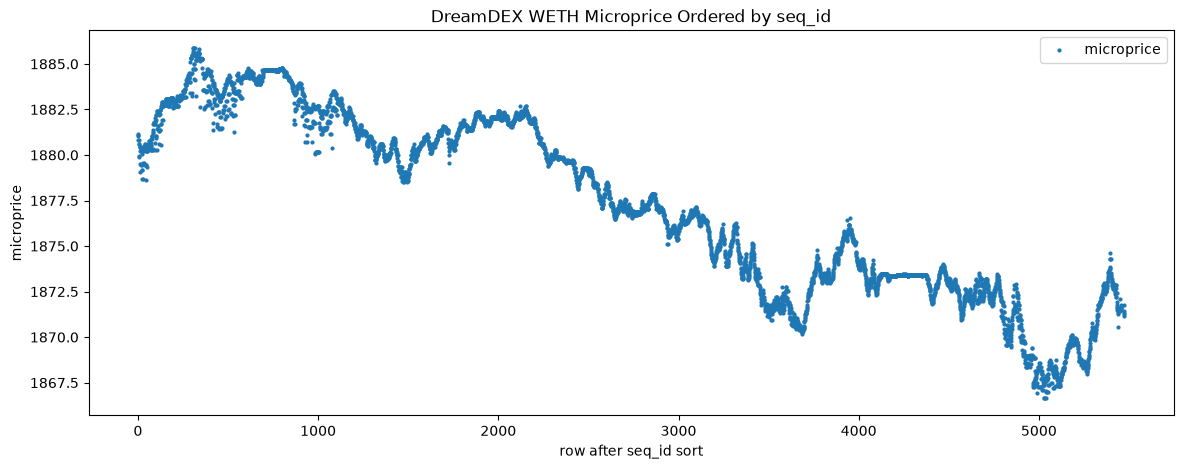

In [44]:
df_plot = df.sort("seq_id").with_row_index("row")

plt.figure(figsize=(14, 5))
plt.scatter(df_plot["row"], df_plot["microprice"], s=4, label="microprice")
plt.title("DreamDEX WETH Microprice Ordered by seq_id")
plt.xlabel("row after seq_id sort")
plt.ylabel("microprice")
plt.legend()
plt.show()